## Project 1 workflow

- RAW DATA
   
- EDA

- Duplicate Detection

- Missing Value Imputation

- IQR Outlier Detection

- IQR Outlier Capping

- FEATURE ENGINEERING

- Clean/Ready Dataset

#### Importing the necessary libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

In [62]:
##Ismporting the dataset
data = pd.read_csv("C:/Users/user/Downloads/decodelabs_project1_practice_dataset.csv")

##### Data Exploration and Understanding

In [63]:
data.head()

,customer_id,age,annual_income,tenure_months,monthly_spend,orders_last_12_months,satisfaction_score,complaints_last_year,support_calls,discount_pct,region,customer_segment,payment_method
0,CUST10001,44.0,118745.04,15.7,100.58,11,8.3,2.0,4,7.3,Port Harcourt,Professional,Bank Transfer
1,CUST10002,36.0,91458.17,2.0,40.52,9,5.3,1.0,3,2.6,Kano,Professional,Cash
2,CUST10003,46.0,56833.72,12.9,77.04,7,7.4,NaN,2,1.3,Lagos,Professional,Bank Transfer
3,CUST10004,56.0,38533.11,3.5,92.81,7,6.4,1.0,4,14.7,Lagos,Business,Bank Transfer
4,CUST10005,35.0,80749.84,49.5,NaN,10,5.1,0.0,3,6.4,Lagos,Family,Cash


In [64]:
data.shape

(1003, 13)

In [65]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            1003 non-null   str    
 1   age                    963 non-null    float64
 2   annual_income          943 non-null    float64
 3   tenure_months          1003 non-null   float64
 4   monthly_spend          953 non-null    float64
 5   orders_last_12_months  1003 non-null   int64  
 6   satisfaction_score     973 non-null    float64
 7   complaints_last_year   963 non-null    float64
 8   support_calls          1003 non-null   int64  
 9   discount_pct           1003 non-null   float64
 10  region                 1003 non-null   str    
 11  customer_segment       1003 non-null   str    
 12  payment_method         1003 non-null   str    
dtypes: float64(7), int64(2), str(4)
memory usage: 102.0 KB


All features are correctly stored but some has missing values which we would handle

In [66]:
data.isna().sum()

customer_id               0
age                      40
annual_income            60
tenure_months             0
monthly_spend            50
orders_last_12_months     0
satisfaction_score       30
complaints_last_year     40
support_calls             0
discount_pct              0
region                    0
customer_segment          0
payment_method            0
dtype: int64

Some features such as age, annual_income, monthly spending etc has missing values. we would handle them later

In [67]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,963.0,38.341641,11.421093,18.0,30.00,38.00,46.000,75.00
annual_income,943.0,70195.632131,59002.410107,10914.8,39953.93,57531.89,82979.365,808203.59
tenure_months,1003.0,29.177368,27.454259,1.0,8.55,20.80,41.350,120.00
monthly_spend,953.0,89.382246,38.507639,20.0,69.94,87.52,104.320,739.29
orders_last_12_months,1003.0,8.440678,7.010202,1.0,6.00,8.00,10.000,100.00
satisfaction_score,973.0,6.941932,1.737456,1.0,5.80,7.00,8.200,10.00
complaints_last_year,963.0,1.562825,1.231495,0.0,1.00,1.00,2.000,6.00
support_calls,1003.0,3.069791,1.762640,0.0,2.00,3.00,4.000,11.00
discount_pct,1003.0,12.381256,5.857255,0.0,8.25,12.30,16.500,30.90


In [68]:
data.duplicated().sum()

np.int64(3)

In [69]:
##checking the age column if there is any outlier
data["age"].value_counts()

age
18.0    41
41.0    40
32.0    39
39.0    37
38.0    35
35.0    34
31.0    34
42.0    32
46.0    31
37.0    31
44.0    30
47.0    29
45.0    28
40.0    28
28.0    27
30.0    26
26.0    24
48.0    24
29.0    24
34.0    23
36.0    22
43.0    22
33.0    22
27.0    19
51.0    18
21.0    17
23.0    17
50.0    16
52.0    16
25.0    15
49.0    15
56.0    12
24.0    12
20.0    12
55.0    12
57.0    11
60.0    10
22.0     9
54.0     9
19.0     8
53.0     8
58.0     8
61.0     7
64.0     5
59.0     5
63.0     4
68.0     2
75.0     2
66.0     2
62.0     2
67.0     2
69.0     2
71.0     1
65.0     1
70.0     1
Name: count, dtype: int64

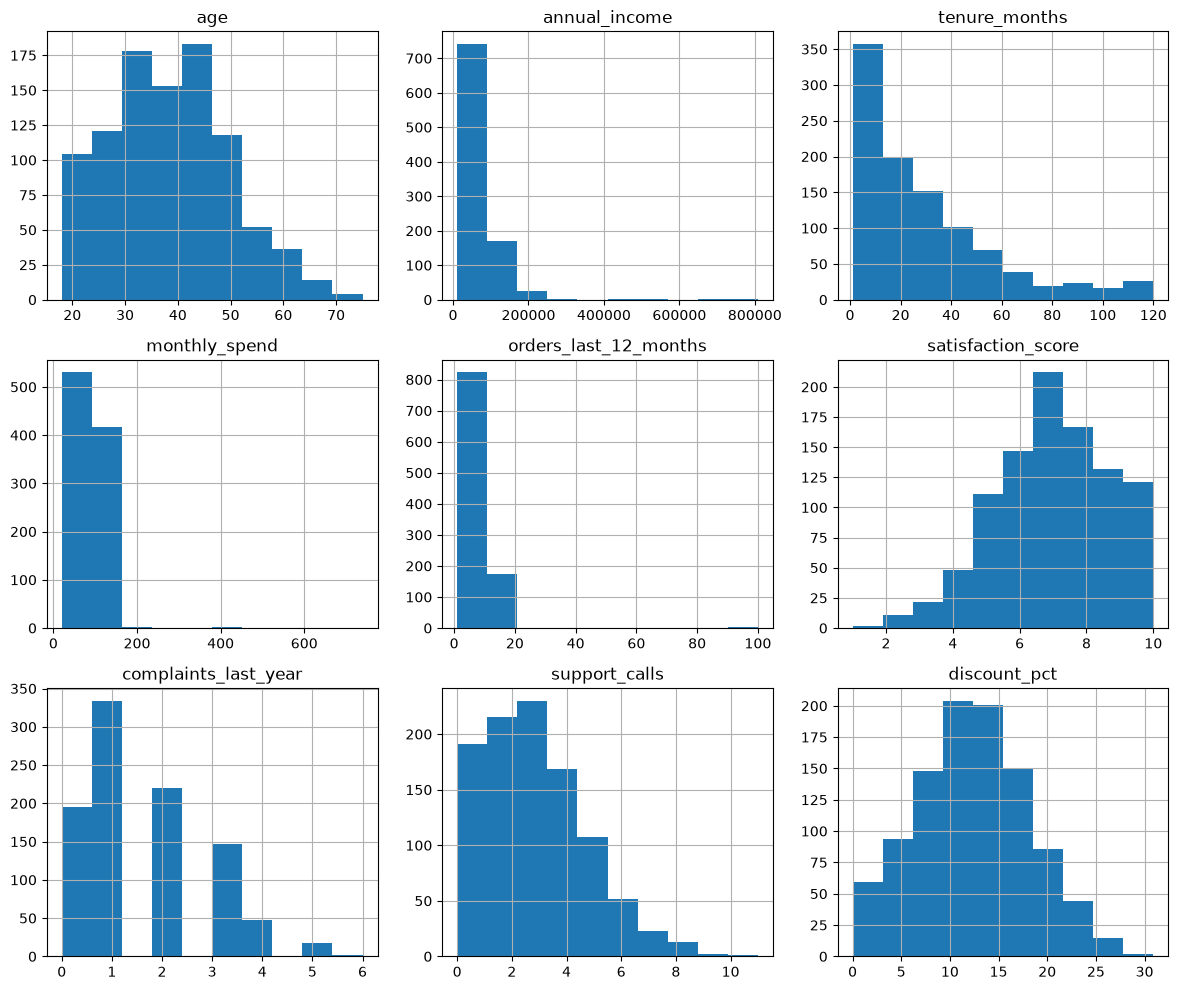

In [70]:
data.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

In [71]:
##Skewness 
data.select_dtypes(include=np.number).skew()

age                       0.268034
annual_income             6.570998
tenure_months             1.414634
monthly_spend             7.051497
orders_last_12_months    11.122377
satisfaction_score       -0.238390
complaints_last_year      0.689873
support_calls             0.574079
discount_pct              0.097691
dtype: float64

Now that we have the insights we need lets create a copy of the original data set before we correct

In [72]:
#Creata a copy of the raw dataset
clean_data = data.copy()

#Removing the 3 duplicate rows we saw earlier
clean_data = clean_data.drop_duplicates()

print("Original rows:", len(data))
print("Rows after removing duplicates: ", len(clean_data))
print("Duplicates removed:", len(data)- len(clean_data))

Original rows: 1003
Rows after removing duplicates:  1000
Duplicates removed: 3


#Handling the Missing Values 

In [73]:
#mean values 
print("Age mean:", clean_data["age"].mean())
print("Satisfaction mean:", clean_data["satisfaction_score"].mean())

#Median values
print("Income median: ", clean_data["annual_income"].median())
print("Monthly spend median: ", clean_data["monthly_spend"].median())
print("Complaints median:", clean_data["complaints_last_year"].median())

Age mean: 38.32083333333333
Satisfaction mean: 6.942268041237114
Income median:  57402.75
Monthly spend median:  87.41999999999999
Complaints median: 1.0


In [74]:
#imputing the values to handle missing values spotted earlier in the dataset 
clean_data["age"] = clean_data["age"].fillna(clean_data["age"].mean())
clean_data["satisfaction_score"] = clean_data["satisfaction_score"].fillna(clean_data["satisfaction_score"].mean())

clean_data["annual_income"] = clean_data["annual_income"].fillna(clean_data["annual_income"].median())
clean_data["monthly_spend"] = clean_data["monthly_spend"].fillna(clean_data["monthly_spend"].median())
clean_data["complaints_last_year"] = clean_data["complaints_last_year"].fillna(clean_data["complaints_last_year"].median())





In [75]:
#Verifying the missing values corrections
clean_data.isna().sum()

customer_id              0
age                      0
annual_income            0
tenure_months            0
monthly_spend            0
orders_last_12_months    0
satisfaction_score       0
complaints_last_year     0
support_calls            0
discount_pct             0
region                   0
customer_segment         0
payment_method           0
dtype: int64

In [76]:
##Calculating the IQR for numerical variables
numeric_columns = clean_data.select_dtypes(include=np.number).columns

for column in numeric_columns:
    Q1 = clean_data[column].quantile(0.25)
    Q3 = clean_data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\n{column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")



age
Q1: 30.00
Q3: 46.00
IQR: 16.00
Lower Bound: 6.00
Upper Bound: 70.00

annual_income
Q1: 40968.98
Q3: 80559.24
IQR: 39590.26
Lower Bound: -18416.40
Upper Bound: 139944.63

tenure_months
Q1: 8.50
Q3: 41.40
IQR: 32.90
Lower Bound: -40.85
Upper Bound: 90.75

monthly_spend
Q1: 70.94
Q3: 103.27
IQR: 32.34
Lower Bound: 22.43
Upper Bound: 151.78

orders_last_12_months
Q1: 6.00
Q3: 10.00
IQR: 4.00
Lower Bound: 0.00
Upper Bound: 16.00

satisfaction_score
Q1: 5.80
Q3: 8.20
IQR: 2.40
Lower Bound: 2.20
Upper Bound: 11.80

complaints_last_year
Q1: 1.00
Q3: 2.00
IQR: 1.00
Lower Bound: -0.50
Upper Bound: 3.50

support_calls
Q1: 2.00
Q3: 4.00
IQR: 2.00
Lower Bound: -1.00
Upper Bound: 7.00

discount_pct
Q1: 8.20
Q3: 16.50
IQR: 8.30
Lower Bound: -4.25
Upper Bound: 28.95


In [77]:
outlier_summary = []

for column in numeric_columns:
    Q1 = clean_data[column].quantile(0.25)
    Q3 = clean_data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = clean_data[
        (clean_data[column] < lower_bound) |
        (clean_data[column] > upper_bound)
    ]
    
    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": (len(outliers) / len(clean_data)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,age,30.0000,46.0000,16.0000,6.00000,70.00000,3,0.3
1,annual_income,40968.9825,80559.2400,39590.2575,-18416.40375,139944.62625,54,5.4
2,tenure_months,8.5000,41.4000,32.9000,-40.85000,90.75000,50,5.0
3,monthly_spend,70.9375,103.2725,32.3350,22.43500,151.77500,16,1.6
4,orders_last_12_months,6.0000,10.0000,4.0000,0.00000,16.00000,5,0.5
5,satisfaction_score,5.8000,8.2000,2.4000,2.20000,11.80000,3,0.3
6,complaints_last_year,1.0000,2.0000,1.0000,-0.50000,3.50000,67,6.7
7,support_calls,2.0000,4.0000,2.0000,-1.00000,7.00000,16,1.6
8,discount_pct,8.2000,16.5000,8.3000,-4.25000,28.95000,1,0.1


In [78]:
#handling outliers
#lets create a copy of the clean dataset to handle outliers
handled_outliers = clean_data.copy()

#lets cap the outliers for each numerical column based on the calculated lower and upper bounds
for column in numeric_columns:
    Q1 = handled_outliers[column].quantile(0.25)
    Q3 = handled_outliers[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping the outliers
    handled_outliers[column] = (handled_outliers[column].clip(lower=lower_bound, upper=upper_bound))

    print(f"Outlier handling completed for column: {column}")

Outlier handling completed for column: age
Outlier handling completed for column: annual_income


Outlier handling completed for column: tenure_months
Outlier handling completed for column: monthly_spend
Outlier handling completed for column: orders_last_12_months
Outlier handling completed for column: satisfaction_score
Outlier handling completed for column: complaints_last_year
Outlier handling completed for column: support_calls
Outlier handling completed for column: discount_pct


#### Lets Verify the treatments

In [79]:
for column in numeric_columns:
    Q1 = handled_outliers[column].quantile(0.25)
    Q3 = handled_outliers[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = handled_outliers[
        (handled_outliers[column] < lower_bound) |
        (handled_outliers[column] > upper_bound)
    ]
    
    print(f"{column}: {len(outliers)} outliers")

age: 0 outliers
annual_income: 0 outliers
tenure_months: 0 outliers
monthly_spend: 0 outliers
orders_last_12_months: 0 outliers
satisfaction_score: 0 outliers
complaints_last_year: 0 outliers
support_calls: 0 outliers
discount_pct: 0 outliers


In [80]:
##Comparison before and after outlier handling
comparison = pd.DataFrame({
    "Before_Min": clean_data[numeric_columns].min(),
    "After_Min": handled_outliers[numeric_columns].min(),
    "Before_Max": clean_data[numeric_columns].max(),
    "After_Max": handled_outliers[numeric_columns].max()
})

comparison

,Before_Min,After_Min,Before_Max,After_Max
age,18.0,18.000,75.00,70.00000
annual_income,10914.8,10914.800,808203.59,139944.62625
tenure_months,1.0,1.000,120.00,90.75000
monthly_spend,20.0,22.435,739.29,151.77500
orders_last_12_months,1.0,1.000,100.00,16.00000
satisfaction_score,1.0,2.200,10.00,10.00000
complaints_last_year,0.0,0.000,6.00,3.50000
support_calls,0.0,0.000,11.00,7.00000
discount_pct,0.0,0.000,30.90,28.95000


In [81]:
handled_outliers.select_dtypes(include=np.number).skew()

age                      0.255929
annual_income            0.863089
tenure_months            1.080119
monthly_spend            0.030035
orders_last_12_months    0.272652
satisfaction_score      -0.214879
complaints_last_year     0.316503
support_calls            0.364392
discount_pct             0.091926
dtype: float64

In [82]:
##Feature Engineering
##For this data set i would be creating 3 additional features; Monthly income, spending ratio and monthly order tenure

#Creating a copy data for the features 
feature_data = handled_outliers.copy()


In [83]:
##Monthly income 
feature_data["monthly_income"] = (feature_data["annual_income"] / 12)

#Spending Ratio 
feature_data["spending_ratio"] = (feature_data["monthly_spend"] /feature_data["monthly_income"]) * 100

#Monthly order tenure
feature_data["orders_per_tenure_month"] = (feature_data["orders_last_12_months"] /feature_data["tenure_months"])

# Checking the features
feature_data[["annual_income","monthly_income","monthly_spend","monthly_income",
              "spending_ratio","orders_last_12_months","tenure_months", "orders_per_tenure_month"]].head()

,annual_income,monthly_income,monthly_spend,monthly_income,spending_ratio,orders_last_12_months,tenure_months,orders_per_tenure_month
0,118745.04,9895.420000,100.58,9895.420000,1.016430,11,15.7,0.700637
1,91458.17,7621.514167,40.52,7621.514167,0.531653,9,2.0,4.500000
2,56833.72,4736.143333,77.04,4736.143333,1.626640,7,12.9,0.542636
3,38533.11,3211.092500,92.81,3211.092500,2.890294,7,3.5,2.000000
4,80749.84,6729.153333,87.42,6729.153333,1.299123,10,49.5,0.202020


In [84]:
##confirming our new features  
feature_data[["monthly_income","spending_ratio","orders_per_tenure_month"]].isna().sum()

monthly_income             0
spending_ratio             0
orders_per_tenure_month    0
dtype: int64

In [85]:
##Inspecting new features

feature_data[["monthly_income","spending_ratio","orders_per_tenure_month"]].describe()

,monthly_income,spending_ratio,orders_per_tenure_month
count,1000.000000,1000.000000,1000.000000
mean,5395.429204,2.093066,1.068026
std,2670.974873,1.393297,1.820346
min,909.566667,0.206224,0.022039
25%,3414.081875,1.166130,0.173985
50%,4783.562500,1.785757,0.367535
75%,6713.270000,2.576416,0.967742
max,11662.052187,13.905775,13.000000


In [86]:
##Final dataset after handling missing values, outliers and feature engineering
#lets validate the final dataset to ensure there are no missing values and all outliers have been handled


print("FINAL DATASET VALIDATION")
print("=" * 50)

# 1. Dataset shape
print("\n1. Dataset Shape")
print(f"Rows: {feature_data.shape[0]}")
print(f"Columns: {feature_data.shape[1]}")

# 2. Data types
print("\n2. Data Types")
print(feature_data.dtypes)

# 3. Missing values
print("\n3. Missing Values")
missing_values = feature_data.isnull().sum()
print(missing_values[missing_values > 0])

# 4. Duplicate records
print("\n4. Duplicate Records")
print(f"Number of duplicate rows: {feature_data.duplicated().sum()}")

# 5. Numerical summary
print("\n5. Numerical Summary")
display(feature_data.describe().T)

# 6. Categorical columns
print("\n6. Categorical Columns")
categorical_columns = feature_data.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns:
    print(f"\n{column}")
    print(feature_data[column].value_counts(dropna=False))

# 7. Numerical columns
print("\n7. Numerical Columns")
numeric_columns = feature_data.select_dtypes(include=np.number).columns

for column in numeric_columns:
    print(f"\n{column}")
    print(f"Minimum: {feature_data[column].min()}")
    print(f"Maximum: {feature_data[column].max()}")

# 8. Negative values
print("\n8. Negative Values")

for column in numeric_columns:
    negative_count = (feature_data[column] < 0).sum()
    
    if negative_count > 0:
        print(f"{column}: {negative_count} negative values")

# 9. Infinite values
print("\n9. Infinite Values")
print(np.isinf(feature_data.select_dtypes(include=np.number)).sum())

print("\n" + "=" * 50)
print("FINAL VALIDATION COMPLETED")

FINAL DATASET VALIDATION

1. Dataset Shape
Rows: 1000
Columns: 16

2. Data Types
customer_id                    str
age                        float64
annual_income              float64
tenure_months              float64
monthly_spend              float64
orders_last_12_months        int64
satisfaction_score         float64
complaints_last_year       float64
support_calls                int64
discount_pct               float64
region                         str
customer_segment               str
payment_method                 str
monthly_income             float64
spending_ratio             float64
orders_per_tenure_month    float64
dtype: object

3. Missing Values
Series([], dtype: int64)

4. Duplicate Records
Number of duplicate rows: 0

5. Numerical Summary


,count,mean,std,min,25%,50%,75%,max
age,1000.0,38.309833,11.165652,18.000000,30.000000,38.320833,46.000000,70.000000
annual_income,1000.0,64745.150447,32051.698478,10914.800000,40968.982500,57402.750000,80559.240000,139944.626250
tenure_months,1000.0,28.337400,25.102075,1.000000,8.500000,20.800000,41.400000,90.750000
monthly_spend,1000.0,87.686280,25.333417,22.435000,70.937500,87.420000,103.272500,151.775000
orders_last_12_months,1000.0,8.021000,2.725801,1.000000,6.000000,8.000000,10.000000,16.000000
satisfaction_score,1000.0,6.944268,1.707428,2.200000,5.800000,6.942268,8.200000,10.000000
complaints_last_year,1000.0,1.484500,1.088207,0.000000,1.000000,1.000000,2.000000,3.500000
support_calls,1000.0,3.054000,1.704109,0.000000,2.000000,3.000000,4.000000,7.000000
discount_pct,1000.0,12.363350,5.848291,0.000000,8.200000,12.200000,16.500000,28.950000
monthly_income,1000.0,5395.429204,2670.974873,909.566667,3414.081875,4783.562500,6713.270000,11662.052187



6. Categorical Columns

customer_id
customer_id
CUST10001    1
CUST10002    1
CUST10003    1
CUST10004    1
CUST10005    1
            ..
CUST10996    1
CUST10997    1
CUST10998    1
CUST10999    1
CUST11000    1
Name: count, Length: 1000, dtype: int64

region
region
Lagos            313
Abuja            221
Ibadan           179
Port Harcourt    171
Kano             116
Name: count, dtype: int64

customer_segment
customer_segment
Professional    334
Family          287
Student         191
Business        188
Name: count, dtype: int64

payment_method
payment_method
Cash             269
USSD             256
Card             245
Bank Transfer    230
Name: count, dtype: int64

7. Numerical Columns

age
Minimum: 18.0
Maximum: 70.0

annual_income
Minimum: 10914.8
Maximum: 139944.62624999997

tenure_months
Minimum: 1.0
Maximum: 90.75

monthly_spend
Minimum: 22.434999999999988
Maximum: 151.77500000000003

orders_last_12_months
Minimum: 1
Maximum: 16

satisfaction_score
Minimum: 2.200000000000

C:\Users\user\AppData\Local\Temp\ipykernel_15176\2971418990.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = feature_data.select_dtypes(


In [87]:
#Some count variables contain decimals which is not logical, lets correct by rounding up to whole numbers

feature_data['age'] = feature_data['age'].round().astype(int)

feature_data['tenure_months'] = feature_data['tenure_months'].round().astype(int)

feature_data['complaints_last_year'] = feature_data['complaints_last_year'].round().astype(int)


In [88]:
# FINAL VALIDATION - AFTER CORRECTIONS

print("FINAL DATASET VALIDATION")
print("=" * 50)

print("\n1. Dataset Shape")
print(f"Rows: {feature_data.shape[0]}")
print(f"Columns: {feature_data.shape[1]}")

print("\n2. Missing Values")
print(feature_data.isnull().sum().sum())

print("\n3. Duplicate Rows")
print(feature_data.duplicated().sum())

print("\n4. Data Types")
print(feature_data.dtypes)

print("\n5. Numerical Summary")
display(feature_data.describe().T)

print("\n6. Infinite Values")
print(np.isinf(feature_data.select_dtypes(include=np.number)).sum().sum())

print("\n7. Negative Values")
negative_values = {}

for column in feature_data.select_dtypes(include=np.number).columns:
    count = (feature_data[column] < 0).sum()
    if count > 0:
        negative_values[column] = count

print(negative_values if negative_values else "No negative values found")

print("\n8. Final Columns")
print(feature_data.columns.tolist())

print("\n" + "=" * 50)
print("FINAL VALIDATION COMPLETED")

FINAL DATASET VALIDATION

1. Dataset Shape
Rows: 1000
Columns: 16

2. Missing Values
0

3. Duplicate Rows
0

4. Data Types
customer_id                    str
age                          int64
annual_income              float64
tenure_months                int64
monthly_spend              float64
orders_last_12_months        int64
satisfaction_score         float64
complaints_last_year         int64
support_calls                int64
discount_pct               float64
region                         str
customer_segment               str
payment_method                 str
monthly_income             float64
spending_ratio             float64
orders_per_tenure_month    float64
dtype: object

5. Numerical Summary


,count,mean,std,min,25%,50%,75%,max
age,1000.0,38.297000,11.165817,18.000000,30.000000,38.000000,46.000000,70.000000
annual_income,1000.0,64745.150447,32051.698478,10914.800000,40968.982500,57402.750000,80559.240000,139944.626250
tenure_months,1000.0,28.353000,25.139220,1.000000,8.000000,21.000000,41.000000,91.000000
monthly_spend,1000.0,87.686280,25.333417,22.435000,70.937500,87.420000,103.272500,151.775000
orders_last_12_months,1000.0,8.021000,2.725801,1.000000,6.000000,8.000000,10.000000,16.000000
satisfaction_score,1000.0,6.944268,1.707428,2.200000,5.800000,6.942268,8.200000,10.000000
complaints_last_year,1000.0,1.518000,1.155427,0.000000,1.000000,1.000000,2.000000,4.000000
support_calls,1000.0,3.054000,1.704109,0.000000,2.000000,3.000000,4.000000,7.000000
discount_pct,1000.0,12.363350,5.848291,0.000000,8.200000,12.200000,16.500000,28.950000
monthly_income,1000.0,5395.429204,2670.974873,909.566667,3414.081875,4783.562500,6713.270000,11662.052187



6. Infinite Values
0

7. Negative Values
No negative values found

8. Final Columns
['customer_id', 'age', 'annual_income', 'tenure_months', 'monthly_spend', 'orders_last_12_months', 'satisfaction_score', 'complaints_last_year', 'support_calls', 'discount_pct', 'region', 'customer_segment', 'payment_method', 'monthly_income', 'spending_ratio', 'orders_per_tenure_month']

FINAL VALIDATION COMPLETED


In [89]:
import os

print(os.getcwd())

c:\Users\user\Desktop\Decode Labs\Decode Labs prj 1\Notebooks


In [90]:
#saving the cleaned dataset
feature_data.to_csv('../data/processed/customer_analysis_cleaned.csv', index=False)